In [1]:
!pip install xgboost

In [2]:
import xgboost as xgb
print(xgb.__version__)

3.1.2


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("dataClean/dataClean.csv")

In [5]:
df.head()

,Unnamed: 0,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False,False,0.057834
1,1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False,False,0.087731
2,2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True,True,0.994505
3,3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False,True,0.994505
4,4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False,False,0.280788


In [6]:
cols_to_drop = ["Unnamed: 0", "step"]
df = df.drop(columns=cols_to_drop, errors="ignore")

In [7]:
df

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999


In [8]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']
#Separation features et label x=features , y=label (isfraud)

In [9]:
df

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999


In [10]:
X

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,9839.64,170136.00,160296.36,0.00,0.00,False,False,True,False,False,0.057834
1,1864.28,21249.00,19384.72,0.00,0.00,False,False,True,False,False,0.087731
2,181.00,181.00,0.00,0.00,0.00,False,False,False,True,True,0.994505
3,181.00,181.00,0.00,21182.00,0.00,True,False,False,False,True,0.994505
4,11668.14,41554.00,29885.86,0.00,0.00,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,339682.13,0.00,0.00,339682.13,True,False,False,False,True,0.999997
6362616,6311409.28,6311409.28,0.00,0.00,0.00,False,False,False,True,True,1.000000
6362617,6311409.28,6311409.28,0.00,68488.84,6379898.11,True,False,False,False,True,1.000000
6362618,850002.52,850002.52,0.00,0.00,0.00,False,False,False,True,True,0.999999


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#X_train → features pour entraîner le modele
#X_test → features pour tester le modele
#y_train → labels correspondants au train
#y_test → labels correspondants au test
#test_size=0.2
#Détermine la proportion du dataset réservé pour le test.
#stratify=y
#Garantit que la proportion de fraudes et non-fraudes est la même dans train et test
#Avec random_state=42 → tu mélanges de façon “aléatoire” mais prévisible : chaque fois que tu recommences, les cartes sont dans le même ordre.

In [12]:
print(y)

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64


In [13]:
# Option pour déséquilibre des classes
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
model = xgb.XGBClassifier(
    n_estimators=200, #Nombre d’arbres que XGBoost va construire.
    max_depth=5, #Profondeur maximale de chaque arbre.
    learning_rate=0.1, #Vitesse d’apprentissage du modèle. Chaque arbre corrige partiellement les erreurs du précédent.
    scale_pos_weight=scale_pos_weight, #Ajuste le déséquilibre des classes.
    tree_method='hist',      # Utilise des histogrammes pour construire les arbres rapidement.
    eval_metric='auc', #Métrique utilisée pendant l’entraînement pour mesurer la qualité des arbres. AUC = "Area Under Curve" → adaptée aux classes déséquilibrées comme la fraude.
    random_state=42 #Fixe le hasard pour que l’entraînement soit reproductible. Chaque fois que tu exécutes le code, tu obtiens le même modèle.
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [14]:
import joblib
joblib.dump(model, 'xgb_modelFraud.pkl')

['xgb_modelFraud.pkl']

In [15]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAUC:", roc_auc_score(y_test, y_pred))
#TN (True Negative) = 1 270 277 : Transactions non-fraudes correctement prédites comme non-fraudes.
#FP (False Positive) = 604 : Transactions non-fraudes prédites comme fraudes (faux alertes).
#FN (False Negative) = 4 : Fraudes prédites comme non-fraudes (fraudes ratées).
#TP (True Positive) = 1 639 : Fraudes correctement détectées.
#Précision: Quand le modèle prédit une fraude, il a 71 % de chance d’avoir raison.
#Rappel: Le modèle détecte toutes les fraudes (aucune n’est ratée quasiment).(la proportion des vrais positifs détectés.)
#F1-score :la moyenne harmonique entre précision et rappel.
#AUC : Capacité globale à séparer fraudes/non-fraudes
#Accuracy : La proportion totale des prédictions correctes (vraies positives + vraies négatives) sur toutes les observations.

Confusion Matrix:
 [[1270227     654]
 [      4    1639]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.71      1.00      0.83      1643

    accuracy                           1.00   1272524
   macro avg       0.86      1.00      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524


AUC: 0.9985254127220786


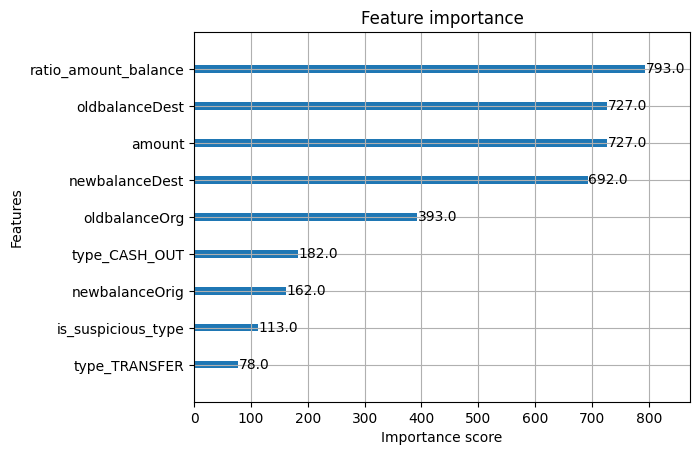

In [16]:
xgb.plot_importance(model)
plt.show()

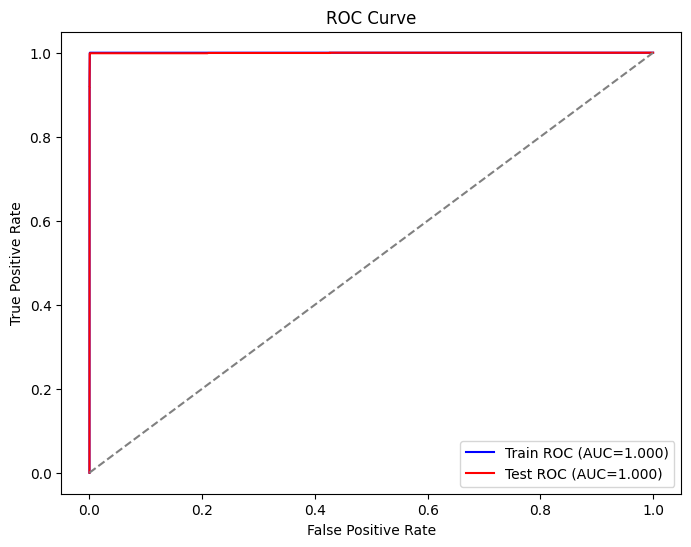

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# ========================
# 1️⃣ Probabilités prédites pour test et train
# ========================
y_train_pred_prob = model.predict_proba(X_train)[:,1]
y_test_pred_prob = model.predict_proba(X_test)[:,1]

# ========================
# 2️⃣ ROC Curve
# ========================
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, color='blue', label=f'Train ROC (AUC={roc_auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='red', label=f'Test ROC (AUC={roc_auc_test:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


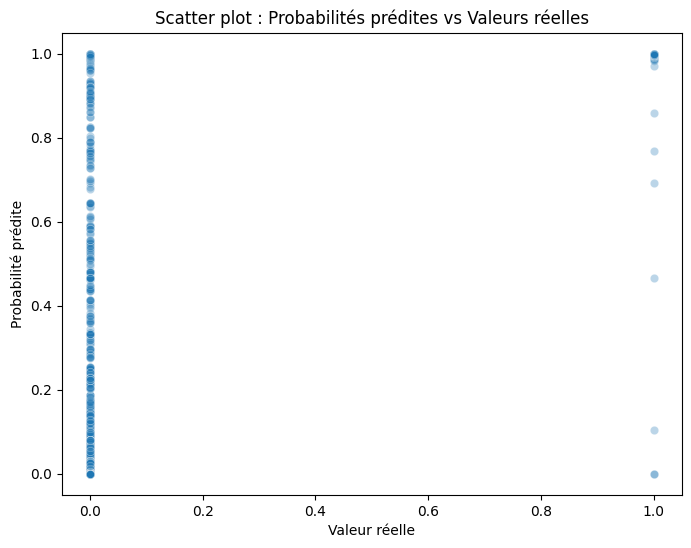

In [18]:
# ========================
# 3️⃣ Scatter plot : prédictions vs valeurs réelles
# ========================
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_test_pred_prob, alpha=0.3)
plt.xlabel('Valeur réelle')
plt.ylabel('Probabilité prédite')
plt.title('Scatter plot : Probabilités prédites vs Valeurs réelles')
plt.show()


In [19]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import streamlit as st
import joblib

In [20]:
from sklearn.metrics import accuracy_score, classification_report

In [21]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print("\n=== TRAIN PERFORMANCE ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

print("\n=== TEST PERFORMANCE ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


=== TRAIN PERFORMANCE ===
Accuracy : 0.9995064926083909
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5083526
           1       0.72      1.00      0.84      6570

    accuracy                           1.00   5090096
   macro avg       0.86      1.00      0.92   5090096
weighted avg       1.00      1.00      1.00   5090096


=== TEST PERFORMANCE ===
Accuracy : 0.9994829174145242
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.71      1.00      0.83      1643

    accuracy                           1.00   1272524
   macro avg       0.86      1.00      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



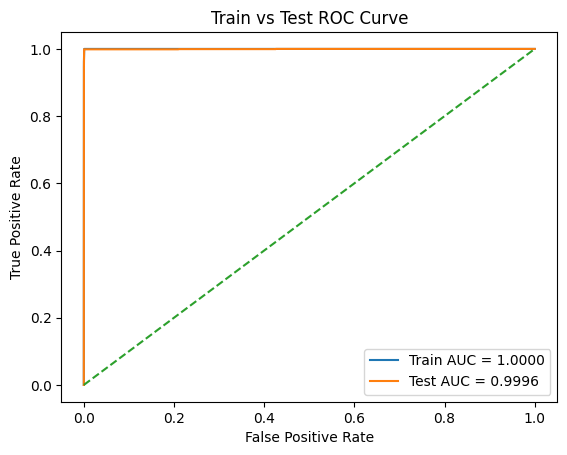

In [22]:

y_train_proba = model.predict_proba(X_train)[:,1]
y_test_proba = model.predict_proba(X_test)[:,1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc(fpr_train, tpr_train):.4f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc(fpr_test, tpr_test):.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("Train vs Test ROC Curve")
plt.show()